# a. Lakukan Exploratory Data Analysis untuk memeriksa kondisi data yang anda miliki, seperti aspect ratio & resolution. Lalu pisahkan data anda menjadi train, validation, dan test dengan proporsi 70:15:15! Lakukan pre-processing pada data anda!

# Pemuatan Data

In [1]:
import zipfile
import os

from PIL import Image, ImageEnhance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

import random

2026-04-21 16:09:54.020637: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776787794.042966    5848 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776787794.050325    5848 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776787794.070305    5848 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776787794.070329    5848 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776787794.070331    5848 computation_placer.cc:177] computation placer alr

In [2]:
# Unzip file 2B.zip
zip_path = '2B.zip'
if os.path.exists(zip_path):
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print(f'File {zip_path} berhasil diekstrak.')
    except zipfile.BadZipFile:
        print(f'Error: {zip_path} bukan merupakan file zip yang valid.')
else:
    print(f'File {zip_path} tidak ditemukan.')

# Root directory
root_dir = "/kaggle/input/datasets/richiedarrian/penyakit-pada-daun-ceri/2C/Cherry/data"

data = []

if os.path.exists(root_dir):
    for label in os.listdir(root_dir):
        class_path = os.path.join(root_dir, label)

        if os.path.isdir(class_path):
            for file in os.listdir(class_path):
                file_path = os.path.join(class_path, file)

                try:
                    data.append({
                        "image_path": file_path,
                        "label": label
                    })

                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
else:
    print(f"Direktori {root_dir} tidak ditemukan. Pastikan path setelah unzip sudah benar.")

# Create DataFrame
df = pd.DataFrame(data)

if not df.empty:
    print(df.head())
    print("Jumlah gambar:", len(df))
else:
    print("DataFrame kosong. Tidak ada data yang dimuat.")

File 2B.zip tidak ditemukan.
                                          image_path                     label
0  /kaggle/input/datasets/richiedarrian/penyakit-...  Cherry_shot hole disease
1  /kaggle/input/datasets/richiedarrian/penyakit-...  Cherry_shot hole disease
2  /kaggle/input/datasets/richiedarrian/penyakit-...  Cherry_shot hole disease
3  /kaggle/input/datasets/richiedarrian/penyakit-...  Cherry_shot hole disease
4  /kaggle/input/datasets/richiedarrian/penyakit-...  Cherry_shot hole disease
Jumlah gambar: 3642


In [3]:
df.head(5)

,image_path,label
0,/kaggle/input/datasets/richiedarrian/penyakit-...,Cherry_shot hole disease
1,/kaggle/input/datasets/richiedarrian/penyakit-...,Cherry_shot hole disease
2,/kaggle/input/datasets/richiedarrian/penyakit-...,Cherry_shot hole disease
3,/kaggle/input/datasets/richiedarrian/penyakit-...,Cherry_shot hole disease
4,/kaggle/input/datasets/richiedarrian/penyakit-...,Cherry_shot hole disease


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3642 entries, 0 to 3641
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  3642 non-null   object
 1   label       3642 non-null   object
dtypes: object(2)
memory usage: 57.0+ KB


# Exploratory Data Analysis (EDA)

### 1. Ekstraksi Fitur Gambar (Dimensi & Aspect Ratio)
Saya perlu menghitung lebar, tinggi, dan aspect ratio dari setiap objek gambar di DataFrame.

In [5]:
# Ekstrak lebar, tinggi, dan aspect ratio dari image_path
def get_image_features(image_path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            aspect_ratio = width / height
            return pd.Series({'width': width, 'height': height, 'aspect_ratio': aspect_ratio})
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return pd.Series({'width': None, 'height': None, 'aspect_ratio': None})

df[['width', 'height', 'aspect_ratio']] = df['image_path'].apply(get_image_features)

display(df[['width', 'height', 'aspect_ratio']].describe())

,width,height,aspect_ratio
count,3642.0,3642.0,3.642000e+03
mean,800.0,1000.0,8.000000e-01
std,0.0,0.0,3.142363e-14
min,800.0,1000.0,8.000000e-01
25%,800.0,1000.0,8.000000e-01
50%,800.0,1000.0,8.000000e-01
75%,800.0,1000.0,8.000000e-01
max,800.0,1000.0,8.000000e-01


Berdasarkan statistik di atas, terlihat bahwa setiap gambar memiliki resolusi yang sama, yaitu 800 x 1000 (width x height). Oleh karena itu, tidak ada permasalahan terkait variasi resolusi data yang mungkin terjadi. Penyesuaian resolusi hanya diperlukan nantinya untuk menyelaraskan dimensi input gambar dengan arsitektur model yang akan dibangun.

### 2. Visualisasi Distribusi Kelas
Memeriksa apakah jumlah sampel antar kelas (label) seimbang.

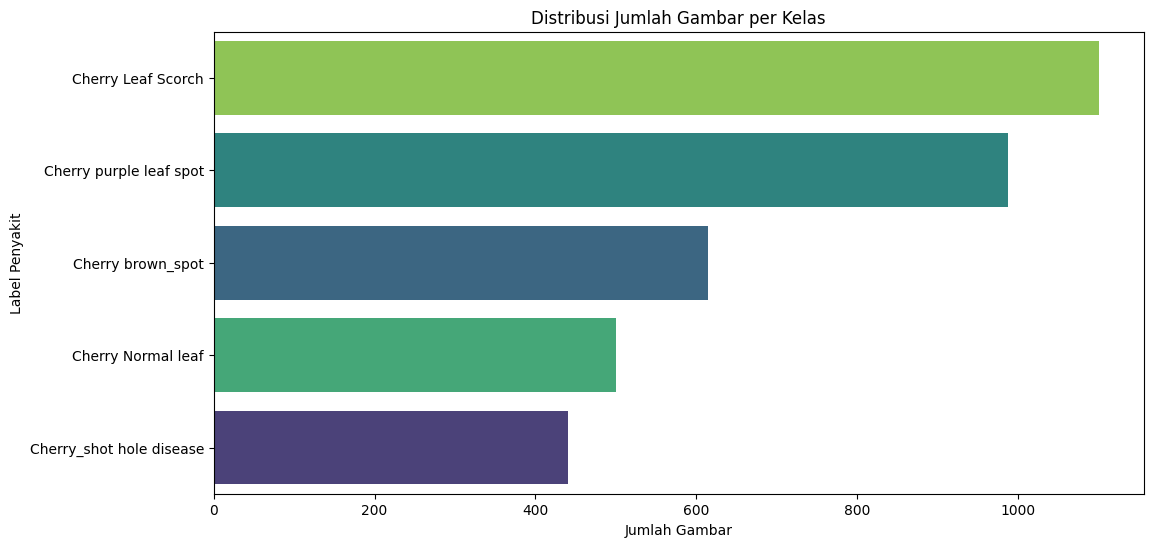

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    y='label',
    hue='label',
    palette='viridis',
    order=df['label'].value_counts().index,
    legend=False
)
plt.title('Distribusi Jumlah Gambar per Kelas')
plt.xlabel('Jumlah Gambar')
plt.ylabel('Label Penyakit')
plt.show()

In [7]:
df['label'].value_counts()

label
Cherry Leaf Scorch          1101
Cherry purple leaf spot      987
Cherry brown_spot            614
Cherry Normal leaf           500
Cherry_shot hole disease     440
Name: count, dtype: int64

Berdasarkan grafik di atas, dapat diamati bahwa:
1. Terdapat variasi jumlah sampel antarkelas cukup besar, yang menunjukkan adanya **data imbalance** (ketidakseimbangan data).
2. Kelas **Cherry Leaf Scorch** memiliki jumlah gambar terbanyak (1101), diikuti oleh **Cherry purple leaf spot**.
3. Kelas **Cherry_shot hole disease** memiliki jumlah gambar paling sedikit (440).

Ketidakseimbangan ini perlu diperhatikan pada tahap prapemrosesan dengan menggunakan teknik *stratified sampling* saat pembagian data (train-test split) serta menambahkan class weights untuk memastikan model dapat mengenali setiap kategori dengan baik.

Ketika saya tidak menggunakan class weights untuk menangani ketidakseimbangan tersebut, model deep learning cenderung sulit untuk mempelajari pola yang ada pada kelas yang jarang (gambar di bawah), khususnya Cherry brown spot. Oleh karena itu, sangat diperlukan class weights untuk menyeimbangkan representasi antarkelas sehingga model bisa generalisasi ke semua penyakit ceri yang ada.

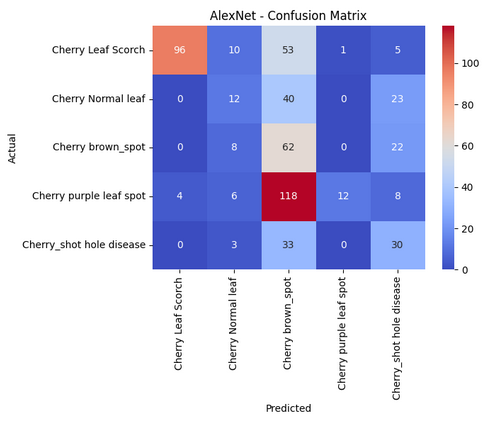

### 3. Menampilkan Contoh Gambar untuk Setiap Kategori

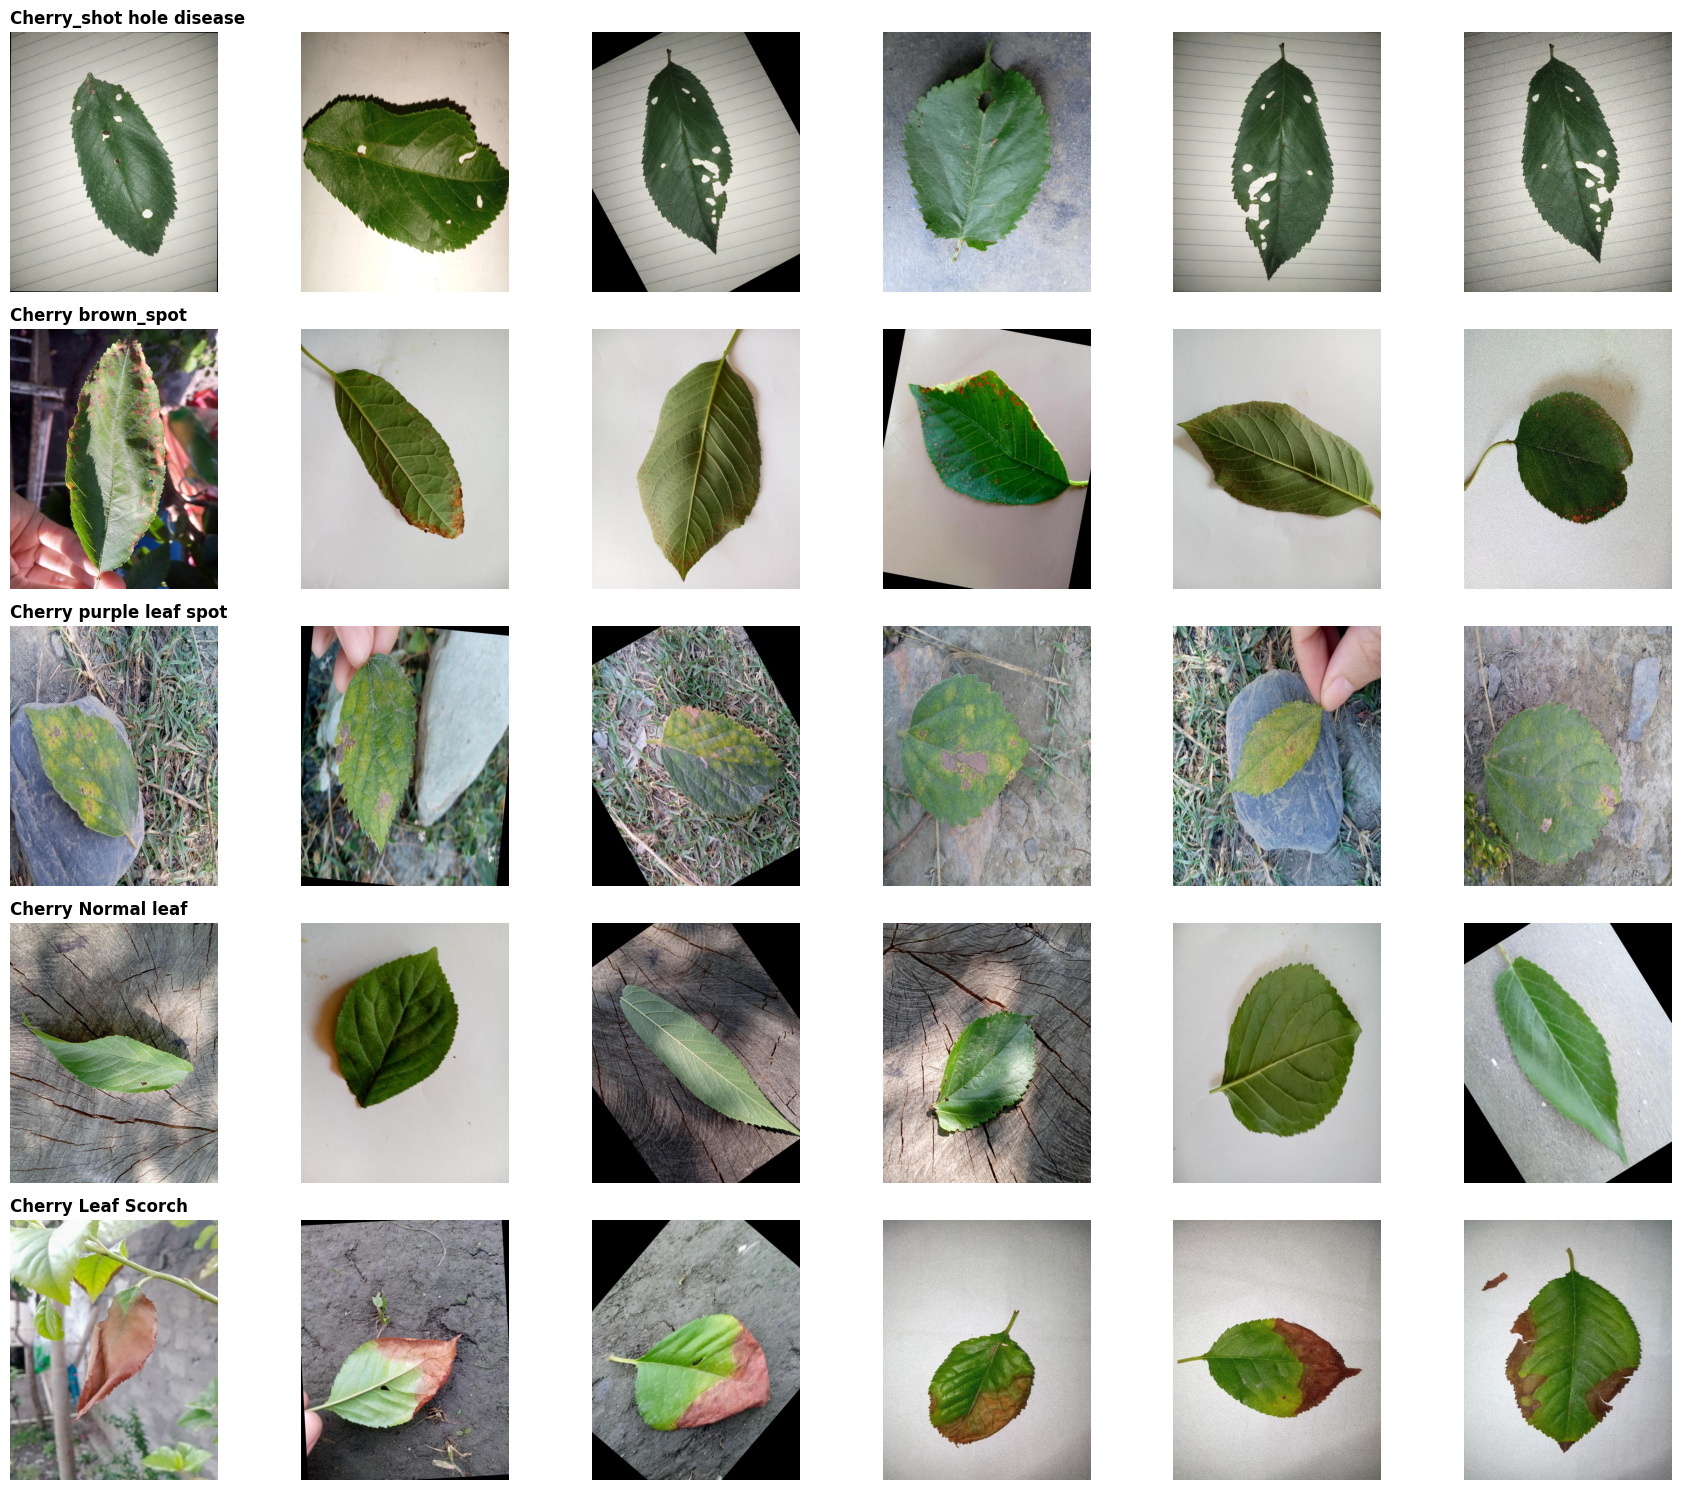

In [8]:
# Menampilkan 6 contoh gambar untuk setiap kategori
unique_labels = df['label'].unique()
num_labels = len(unique_labels)
num_images_per_label = 6

fig, axes = plt.subplots(num_labels, num_images_per_label, figsize=(18, 3 * num_labels))

for i, label in enumerate(unique_labels):
    sample_df = df[df['label'] == label].sample(num_images_per_label, random_state=42)

    for j in range(num_images_per_label):
        image_path = sample_df.iloc[j]['image_path']
        with Image.open(image_path) as img:
            if num_labels == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(f"{label}", loc='left', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

Berdasarkan tampilan sampel gambar di atas, berikut adalah karakteristik visual untuk masing-masing kategori:

1.  **Cherry Leaf Scorch**. Terlihat adanya area kecokelatan yang kering (seperti terbakar) mulai dari tepi daun yang meluas ke bagian tengah.
2.  **Cherry Normal leaf**. Daun tampak sehat dengan warna hijau yang merata, tekstur yang halus, dan tidak memiliki bercak atau kerusakan fisik yang signifikan.
3.  **Cherry_shot hole disease**. Karakteristik utama adalah adanya lubang-lubang kecil pada daun yang menyerupai bekas tembakan peluru, seringkali dikelilingi oleh sedikit area nekrotik.
4.  **Cherry purple leaf spot**. Terdapat bercak-bercak berwarna ungu atau kemerahan yang tersebar di permukaan daun. Bercak ini biasanya memiliki batas yang jelas.
5.  **Cherry brown_spot**. Ditandai dengan munculnya bintik-bintik cokelat kecil yang bisa menyatu menjadi area nekrotik yang lebih besar seiring perkembangan penyakit.

Observasi ini memvalidasi bahwa setiap kelas memiliki fitur visual yang cukup unik sehingga model klasifikasi citra (CNN) diharapkan dapat mempelajari pola-pola tersebut untuk melakukan identifikasi secara otomatis. Namun, terlihat ada tantangan model untuk mempelajari gambar yang diputar beberapa derajat sehingga model harus dilatih untuk memprediksi gambar yang diaugmentasi itu.

# Data Splitting

Memisahkan data menjadi subset **Training**, **Validation**, dan **Test** dengan rasio **70:15:15**. Menggunakan `stratify` sangat penting di sini karena kita telah mengidentifikasi adanya ketidakseimbangan data (*data imbalance*).

In [9]:
# Memisahkan Train (70%) dan Sisa (30% untuk Val & Test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=1,
    stratify=df['label']
)

# Memisahkan sisa menjadi Validation (15%) dan Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=1,
    stratify=temp_df['label']
)

# Verifikasi jumlah data
print(f"Jumlah Data Train     : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Jumlah Data Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Jumlah Data Test       : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# Hapus df dari memori setelah splitting selesai
del df

Jumlah Data Train     : 2549 (70.0%)
Jumlah Data Validation: 546 (15.0%)
Jumlah Data Test       : 547 (15.0%)


In [10]:
# Verifikasi distribusi kelas pada setiap subset
summary_split = pd.DataFrame({
    'Train': train_df['label'].value_counts(normalize=True),
    'Validation': val_df['label'].value_counts(normalize=True),
    'Test': test_df['label'].value_counts(normalize=True)
})

print("Proporsi distribusi kelas di setiap split (harus serupa):")
display(summary_split)

Proporsi distribusi kelas di setiap split (harus serupa):


,Train,Validation,Test
label,,,
Cherry Leaf Scorch,0.302079,0.302198,0.303473
Cherry purple leaf spot,0.271087,0.271062,0.270567
Cherry brown_spot,0.168694,0.168498,0.168190
Cherry Normal leaf,0.137309,0.137363,0.137112
Cherry_shot hole disease,0.120832,0.120879,0.120658


# Preprocessing

Sebelum melatih model, kita perlu mempersiapkan data gambar dan label. Ini meliputi:
1.  **Label Encoding.** Mengubah label kategorikal ke dalam format numerik.
2.  **Image Data Generators.** Menggunakan `ImageDataGenerator` untuk pemuatan, prapemrosesan (penyekalaan ulang), dan augmentasi data yang efisien untuk training set.

In [11]:
le = LabelEncoder()
train_labels = le.fit_transform(train_df['label'])
val_labels = le.transform(val_df['label'])
test_labels = le.transform(test_df['label'])
num_classes = len(le.classes_)

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("tf.data.Dataset pipelines berhasil dibuat.")

Found 2549 validated image filenames belonging to 5 classes.
Found 546 validated image filenames belonging to 5 classes.
tf.data.Dataset pipelines berhasil dibuat.


# b. Buatlah sebuah model CNN dengan arsitektur AlexNet secara manual (tidak menggunakan pre-trained model dari Keras atau Pytorch) seperti pada gambar di samping dan adaptasikan output layer pada gambar sesuai dengan dataset anda. Model ini akan disebut sebagai Baseline Model. Lakukan training pada model anda dengan minimal 10 epoch dan analisis hasilnya.

## Arsitektur Model AlexNet

In [13]:
def alexnet_model(input_shape=(224, 224, 3), num_classes=5):
    model = models.Sequential([
        # Input Layer
        layers.Input(shape=input_shape),
        # Layer 1
        layers.Conv2D(96, (11, 11), strides=4, activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),
        # Layer 2
        layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),
        # Layer 3
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        # Layer 4
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        # Layer 5
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),
        # Flatten
        layers.Flatten(),
        # Fully Connected Layers
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        # Output Layer (Adapted to num_classes)
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

## Build, Compile, and Train the AlexNet Model

In [24]:
classes = np.unique(train_df['label'])

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label']
)

class_weights = dict(zip(classes, weights))

class_weights

{'Cherry Leaf Scorch': np.float64(0.662077922077922),
 'Cherry Normal leaf': np.float64(1.4565714285714286),
 'Cherry brown_spot': np.float64(1.1855813953488372),
 'Cherry purple leaf spot': np.float64(0.7377713458755427),
 'Cherry_shot hole disease': np.float64(1.655194805194805)}

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model = alexnet_model(num_classes=num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=80,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 37s 401ms/step - accuracy: 0.3329 - loss: 1.5277 - val_accuracy: 0.5348 - val_loss: 1.1635
Epoch 2/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 292ms/step - accuracy: 0.5500 - loss: 1.1400 - val_accuracy: 0.6703 - val_loss: 0.9209
Epoch 3/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 301ms/step - accuracy: 0.6429 - loss: 0.9252 - val_accuracy: 0.7143 - val_loss: 0.7927
Epoch 4/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 300ms/step - accuracy: 0.6568 - loss: 0.8724 - val_accuracy: 0.7491 - val_loss: 0.6725
Epoch 5/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 306ms/step - accuracy: 0.7404 - loss: 0.6943 - val_accuracy: 0.7344 - val_loss: 0.6573
Epoch 6/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 297ms/step - accuracy: 0.7801 - loss: 0.5927 - val_accuracy: 0.7930 - val_loss: 0.5410
Epoch 7/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 304ms/step - accuracy: 0.8096 - loss: 0.5015 - val_accuracy: 0.8150 - val_loss: 0.4835
Epoch 8/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 303ms/step - accuracy: 0.8278 - loss: 0.4633 - val_accu

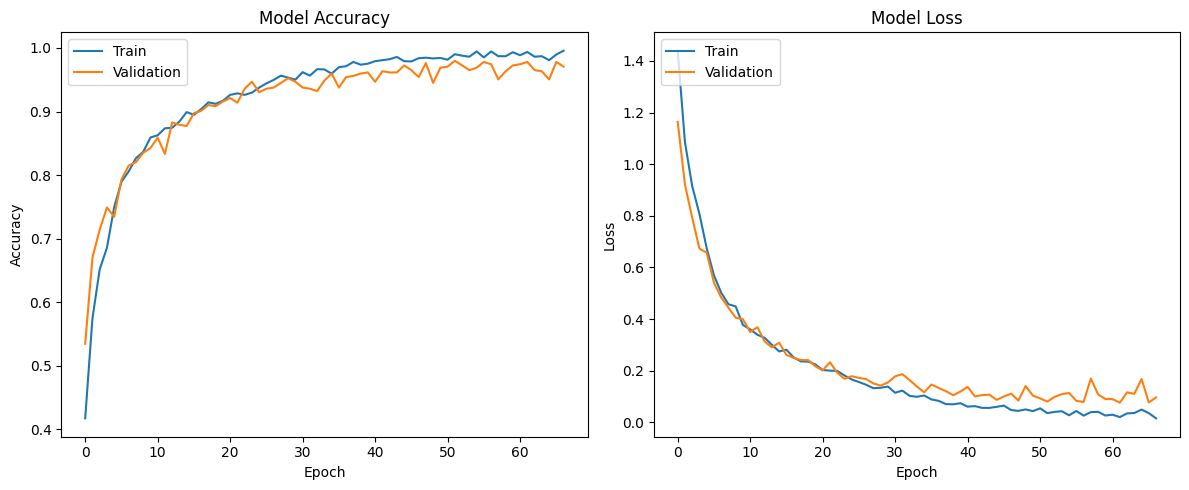

Found 547 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - accuracy: 0.9675 - loss: 0.1308
Test Loss: 0.1312
Test Accuracy: 0.9634


In [26]:
# 1. Visualisasi Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# 2. Mengevaluasi model pada test set
test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

loss, accuracy = model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Model klasifikasi penyakit daun ceri berbasis arsitektur AlexNet **menunjukkan performa yang sangat baik dan stabil**. Hal ini terlihat dari kurva training accuracy yang meningkat secara konsisten hingga mendekati 0.99, serta validation accuracy yang juga tinggi dan stabil di kisaran 0.96-0.98. Gap antara keduanya relatif kecil, yang menunjukkan bahwa model tidak mengalami overfitting yang signifikan meskipun di beberapa epoch akhir terlihat fluktuasi kecil pada validation accuracy yang mengindikasikan overfitting ringan.

Dari sisi loss, **baik training loss maupun validation loss mengalami penurunan yang tajam di awal pelatihan dan kemudian melandai hingga mencapai nilai yang sangat rendah** (sekitar ~0.05–0.15 untuk training dan ~0.10–0.15 untuk validation). Pola ini menunjukkan bahwa proses pembelajaran berjalan efektif dan model mampu menangkap pola data dengan baik tanpa kehilangan kemampuan generalisasi.

Hasil evaluasi pada test set semakin memperkuat temuan ini, dengan test accuracy sebesar 96.34% dan test loss sebesar 0.1312. Nilai ini sangat konsisten dengan performa pada validation set, yang berarti model memiliki kemampuan generalisasi yang kuat terhadap data baru.

Secara keseluruhan, model dapat dikatakan sangat andal untuk tugas klasifikasi ini. Namun, untuk penyempurnaan lebih lanjut, masih bisa dipertimbangkan teknik seperti regularisasi tambahan atau architecture refining untuk mengurangi fluktuasi kecil di akhir training dan memastikan performa tetap optimal secara konsisten.

# c. Modifikasi arsitektur AlexNet yang sudah dibuat. Anda bisa menambahkan DropOut, Batch Normalization, dan sebagainya atau melakukan fine-tuning untuk hyperparameter pada model ini. Anda juga bisa mengganti modelnya dengan arsitektur CNN lain seperti DenseNet, EfficientNet, dan sebagainya. Jelaskan alasan modifikasi anda dan lakukan training (minimal 10 epoch), serta analisis hasilnya

# Modifikasi Arsitektur Model

Berikut modifikasi-modifikasi yang dilakukan beserta alasannya.
- **Beralih dari AlexNet (baseline) ke DenseNet121 pretrained**. Karena DenseNet merupakan arsitektur yang lebih modern dan efisien dalam propagasi fitur melalui koneksi dense sehingga mampu menangkap pola lebih kompleks dan biasanya memberikan akurasi lebih tinggi dibanding CNN klasik seperti AlexNet.
- **Menggunakan pretrained weights dari ImageNet**. Transfer learning memungkinkan model memanfaatkan fitur umum seperti edge, tekstur, dan bentuk yang sudah dipelajari dari dataset besar sehingga performa meningkat meskipun data terbatas.
- **Membekukan (trainable=False) base model DenseNet**. Agar fitur dasar yang sudah kuat tidak rusak selama training awal dan untuk menghindari overfitting pada dataset yang relatif kecil.
- **Mengganti Flatten (AlexNet) dengan GlobalAveragePooling2D**. Untuk mengurangi jumlah parameter secara drastis sehingga model lebih ringan, lebih cepat dilatih, dan lebih tahan terhadap overfitting.
- **Menambahkan BatchNormalization setelah feature extractor**. Untuk menstabilkan distribusi aktivasi sehingga training lebih cepat konvergen dan lebih stabil dibanding AlexNet yang tidak menggunakannya.
- **Mengurangi ukuran fully connected layer dari 4096 (AlexNet) menjadi 256**. Karena DenseNet sudah menghasilkan fitur yang sangat informatif sehingga tidak membutuhkan layer besar dan ini juga membantu mengurangi risiko overfitting.
- **Menyesuaikan preprocessing menggunakan preprocess_input DenseNet**. Agar distribusi input sesuai dengan yang digunakan saat pretraining sehingga performa transfer learning optimal.
- **Menaikkan learning rate dari 0.00001 ke 0.0001**. Karena hanya melatih bagian classifier, model bisa belajar lebih cepat tanpa merusak bobot pretrained.
- **Mengurangi jumlah epoch (80 -> 50)**. Karena transfer learning membuat model lebih cepat konvergen sehingga tidak membutuhkan training selama baseline dari nol.

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1]
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input 
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Data generator dengan DenseNet preprocessing siap digunakan.")

Found 2549 validated image filenames belonging to 5 classes.
Found 546 validated image filenames belonging to 5 classes.
Data generator dengan DenseNet preprocessing siap digunakan.


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

def densenet_model(input_shape=(224, 224, 3), num_classes=5):
    base_model = tf.keras.applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

new_model = densenet_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=num_classes
)

new_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,285 (27.87 MB)

 Trainable params: 265,733 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [19]:
# Melatih model baru (Densenet)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

new_history = new_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 89s 769ms/step - accuracy: 0.3661 - loss: 1.6750 - val_accuracy: 0.7454 - val_loss: 0.8271
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 303ms/step - accuracy: 0.7822 - loss: 0.6209 - val_accuracy: 0.8938 - val_loss: 0.4789
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 298ms/step - accuracy: 0.8764 - loss: 0.3971 - val_accuracy: 0.9212 - val_loss: 0.3312
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 324ms/step - accuracy: 0.8949 - loss: 0.3095 - val_accuracy: 0.9432 - val_loss: 0.2466
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 301ms/step - accuracy: 0.9194 - loss: 0.2541 - val_accuracy: 0.9524 - val_loss: 0.1959
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 298ms/step - accuracy: 0.9258 - loss: 0.2279 - val_accuracy: 0.9579 - val_loss: 0.1603
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 306ms/step - accuracy: 0.9444 - loss: 0.1896 - val_accuracy: 0.9652 - val_loss: 0.1355
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 300ms/step - accuracy: 0.9399 - loss: 0.1715 - val_accu

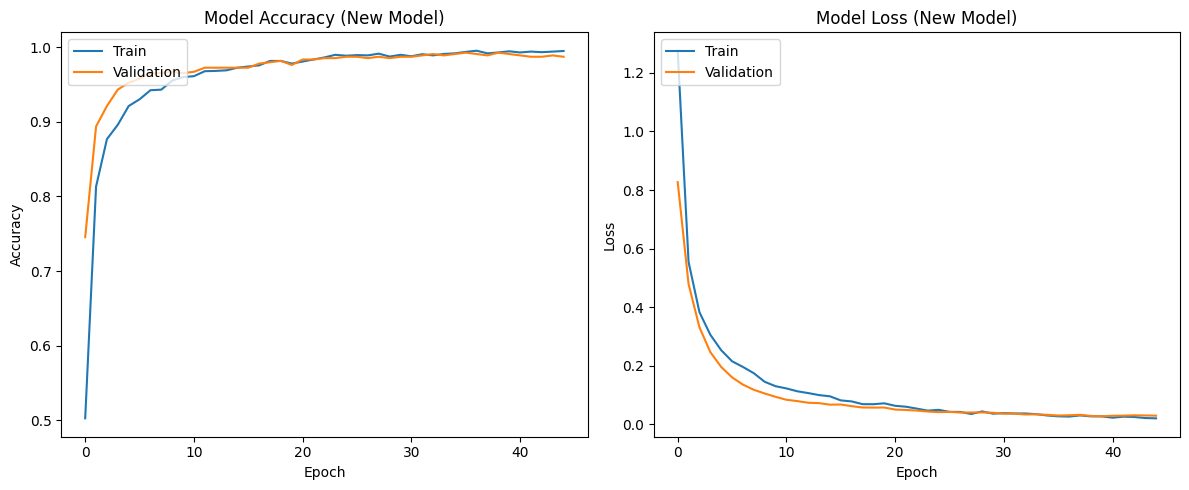

Found 547 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 777ms/step - accuracy: 0.9933 - loss: 0.0300
Test Loss: 0.0310
Test Accuracy: 0.9909


In [20]:
import matplotlib.pyplot as plt

# 1. Visualisasi Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(new_history.history['accuracy'])
plt.plot(new_history.history['val_accuracy'])
plt.title('Model Accuracy (Model Baru)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(new_history.history['loss'])
plt.plot(new_history.history['val_loss'])
plt.title('Model Loss (Model Baru)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# 2. Mengevaluasi new_model pada test set
test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

loss, accuracy = new_model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Model hasil modifikasi berbasis DenseNet menunjukkan **performa yang sangat tinggi dan stabil**, terlihat dari kurva training dan validation accuracy yang meningkat cepat hingga mendekati 0.99 dengan gap yang sangat kecil, menandakan hampir tidak ada overfitting. Penurunan training dan validation loss juga sangat konsisten dan mendekati nol (~0.02–0.05) dengan kedua kurva yang hampir saling berimpit, menunjukkan kemampuan generalisasi yang sangat baik. Hal ini diperkuat oleh hasil evaluasi pada test set dengan akurasi 99.09% dan loss 0.0310 yang sejalan dengan performa validation sehingga dapat disimpulkan bahwa model mampu mengenali pola dengan sangat efektif pada data baru. Peningkatan ini menunjukkan keberhasilan penggunaan transfer learning DenseNet dibandingkan baseline AlexNet, baik dari segi kecepatan konvergensi, stabilitas training, maupun akurasi akhir.

# d. Lakukan evaluasi performa model anda pada data test dengan menggunakan minimal 3 evaluation metrics. Analisis, jelaskan, dan simpulkan hasilnya. Lalu, berikan saran untuk pengembangan lebih lanjut dari model anda.

# Evaluasi Akhir Kedua Model pada Data Test

In [27]:
y_true = val_generator.classes

y_pred_alex = np.argmax(model.predict(val_generator), axis=1)
y_pred_dense = np.argmax(new_model.predict(val_generator), axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step


In [28]:
# ===== AlexNet =====
acc_alex = accuracy_score(y_true, y_pred_alex)
prec_alex = precision_score(y_true, y_pred_alex, average='weighted')
rec_alex = recall_score(y_true, y_pred_alex, average='weighted')
f1_alex = f1_score(y_true, y_pred_alex, average='weighted')

# ===== DenseNet =====
acc_dense = accuracy_score(y_true, y_pred_dense)
prec_dense = precision_score(y_true, y_pred_dense, average='weighted')
rec_dense = recall_score(y_true, y_pred_dense, average='weighted')
f1_dense = f1_score(y_true, y_pred_dense, average='weighted')

# Print hasil
print("=== AlexNet ===")
print(f"Accuracy : {acc_alex:.4f}")
print(f"Precision: {prec_alex:.4f}")
print(f"Recall   : {rec_alex:.4f}")
print(f"F1-Score : {f1_alex:.4f}")

print("\n=== DenseNet ===")
print(f"Accuracy : {acc_dense:.4f}")
print(f"Precision: {prec_dense:.4f}")
print(f"Recall   : {rec_dense:.4f}")
print(f"F1-Score : {f1_dense:.4f}")

=== AlexNet ===
Accuracy : 0.9780
Precision: 0.9782
Recall   : 0.9780
F1-Score : 0.9779

=== DenseNet ===
Accuracy : 0.9908
Precision: 0.9909
Recall   : 0.9908
F1-Score : 0.9908


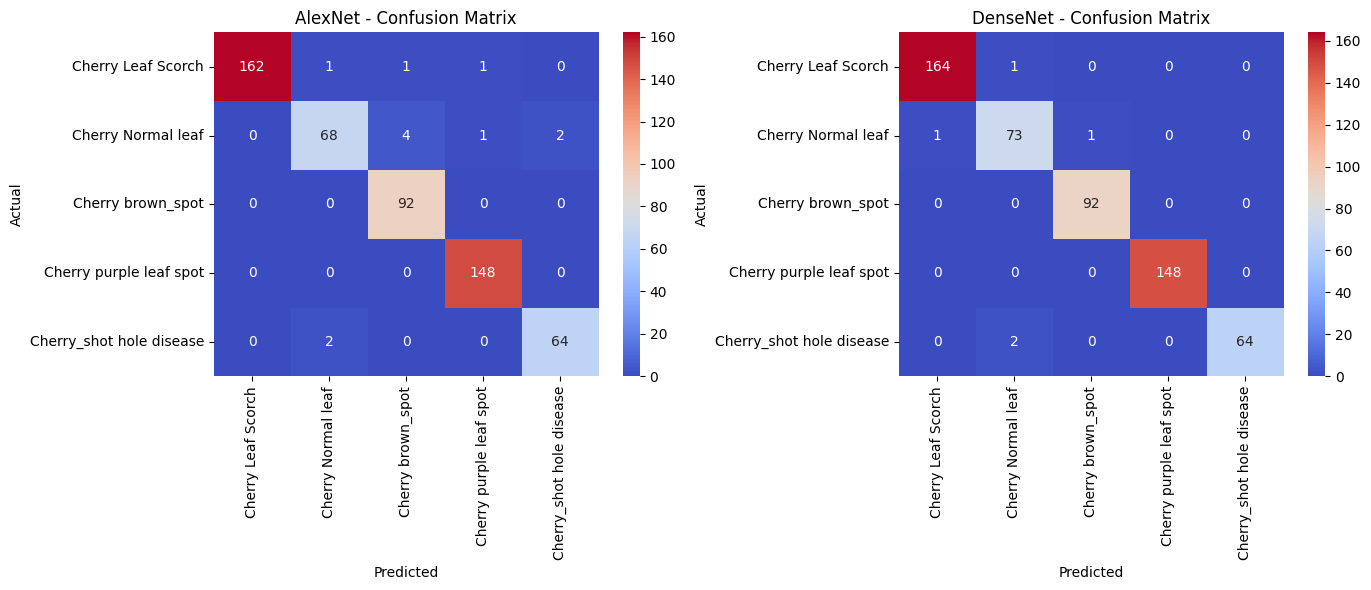

In [29]:
# Confusion matrices
cm_alex = confusion_matrix(y_true, y_pred_alex)
cm_dense = confusion_matrix(y_true, y_pred_dense)

# Ambil label kelas
class_names = list(val_generator.class_indices.keys())

plt.figure(figsize=(14, 6))

# AlexNet
plt.subplot(1, 2, 1)
sns.heatmap(
    cm_alex,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('AlexNet - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# DenseNet
plt.subplot(1, 2, 2)
sns.heatmap(
    cm_dense,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('DenseNet - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

Secara keseluruhan, **kedua model menunjukkan performa yang sangat baik**, tetapi model berbasis DenseNet memberikan hasil yang lebih unggul dan konsisten dibandingkan AlexNet. Dari confusion matrix, AlexNet masih menunjukkan beberapa kesalahan klasifikasi kecil, terutama pada kelas Cherry Normal leaf yang kadang tertukar dengan Cherry brown spot atau kelas lain, serta sedikit kesalahan pada Cherry Leaf Scorch. Meskipun demikian, sebagian besar prediksi tetap berada pada diagonal utama, yang menandakan performa sudah sangat baik (akurasi ~97.8%). Sebaliknya, DenseNet menghasilkan confusion matrix yang jauh lebih bersih, dengan hampir seluruh prediksi tepat di diagonal dan hanya sedikit kesalahan minor (misalnya kebingungan kecil antara Cherry Normal leaf dan kelas lain). Hal ini tercermin pada metrik evaluasi yang meningkat secara konsisten (akurasi, precision, recall, dan F1-score semuanya 99.08–99.09%), menunjukkan bahwa model tidak hanya akurat secara keseluruhan tetapi juga seimbang dalam mengenali semua kelas.

Peningkatan ini mengindikasikan bahwa **penggunaan transfer learning dengan DenseNet mampu menangkap fitur yang lebih representatif dibandingkan AlexNet yang dilatih dari nol** sehingga menghasilkan generalisasi yang lebih baik dan kesalahan klasifikasi yang lebih minim. Selain itu, distribusi kesalahan yang sangat kecil dan tidak terfokus pada satu kelas tertentu menunjukkan bahwa model tidak bias dan mampu mengenali semua kategori penyakit dengan baik.

Sebagai kesimpulan, **model DenseNet merupakan pilihan yang lebih optimal untuk tugas klasifikasi penyakit daun ceri karena memberikan performa yang lebih tinggi, stabil, dan generalizable dibandingkan AlexNet**. Namun, untuk pengembangan lebih lanjut, beberapa hal masih dapat dilakukan, seperti melakukan fine-tuning pada sebagian layer DenseNet (membuka beberapa layer terakhir) untuk meningkatkan performa lebih jauh, menambahkan lebih banyak variasi data augmentation (misalnya rotasi, zoom, atau perubahan kontras) agar model lebih robust terhadap kondisi nyata, serta melakukan evaluasi pada dataset eksternal untuk memastikan tidak terjadi overfitting tersembunyi atau data leakage.

# e. Buatlah video presentasi yang menjelaskan langkah-langkah pengerjaan anda serta hasil analisis anda dengan durasi maksimal 12 menit.

Link Video Penjelasan: https://drive.google.com/drive/folders/1FzyANiJfF5eEne3x5N-e_b0WB-SoJ-9P?usp=sharing